# Korrelation zwischen Alphabetisierungsrate und BIP pro Kopf

## Gruppe: 
Lia Bütikofer (buetilia@students.zhaw.ch), Vanessa Cakoncev (cakonvan@students.zhaw.ch), Lilia Totila (totillil@students.zhaw.ch)

## Fragestellung
Besteht ein Zusammenhang zwischen dem Bruttoinlandsprodukt (BIP) pro Kopf und der Analphabetisierungsrate, und wie zeigt sich dieser Zusammenhang weltweit, sowie in ausgewählten Ländern?

## Quellen
https://ourworldindata.org/grapher/literacy-rate-vs-gdp-per-capita


## 1. Daten beschaffen und laden

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. KONFIGURATION ---
file_path = "literacy-rate-vs-gdp-per-capita.csv"
start_year = 1990
end_year = 2023
target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 
pd.set_option('display.max_rows', 10) # Setzt die maximale Zeilenanzahl für eine übersichtlichere Ausgabe

# --- 2. DATEN LADEN & GLOBALE FILTERUNG ---

try:
    df_rohdaten = pd.read_csv(file_path)
except FileNotFoundError:
    print("FATALER FEHLER: Die Datei 'literacy-rate-vs-gdp-per-capita.csv' wurde nicht gefunden.")
    print("Bitte stellen Sie sicher, dass die Datei im selben Verzeichnis wie das Notebook liegt.")
    exit()

# Sicherstellen, dass die Spalte 'Year' numerisch ist
df_rohdaten['Year'] = pd.to_numeric(df_rohdaten['Year'], errors='coerce')

# Global gefilterter DataFrame (Weltweit, 1990-2023)
df_global_filtered = df_rohdaten[
    (df_rohdaten['Year'] >= start_year) & 
    (df_rohdaten['Year'] <= end_year)
].copy()

# --- 3. SPALTEN UMBENENNEN & VORBEREITUNG ---

df_global_filtered.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    'Literacy rate among adults': 'Alphabetisierungsrate',
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)

# Spezifischer DataFrame für die 4 Zielländer
df_zielgruppe = df_global_filtered[df_global_filtered['Land'].isin(target_countries)].copy()
df_zielgruppe['Analphabetisierungsrate (%)'] = 100 - df_zielgruppe['Alphabetisierungsrate']


print("--- ✅ BASIS-DATENFRAMES ERSTELLT ---")
print("Für globale Analysen: df_global_filtered")
print("Für Länderspezifische Analysen: df_zielgruppe")

--- ✅ BASIS-DATENFRAMES ERSTELLT ---
Für globale Analysen: df_global_filtered
Für Länderspezifische Analysen: df_zielgruppe


In [111]:
df = pd.read_csv("literacy-rate-adults.csv")
df_gdp = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")
df.head()

,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)"
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [87]:
import pandas as pd

# Laden der Haupt-Quelldatei
df_rohdaten = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

# Korrekte Zählung: 'Entity' ist der Name der Länder-Spalte in der Rohdatei.
anzahl_laender = df_rohdaten["Entity"].nunique()

# Ausgabe der Zählung
print("Anzahl verschiedener Länder:", anzahl_laender)

Anzahl verschiedener Länder: 310


In [88]:
df["Entity"].value_counts().head(10)

Entity
Latin America and Caribbean (WB)                            50
Middle East, North Africa, Afghanistan and Pakistan (WB)    50
Lower-middle-income countries                               49
South Asia (WB)                                             49
East Asia and Pacific (WB)                                  48
World                                                       48
Upper-middle-income countries                               48
Sub-Saharan Africa (WB)                                     39
Low-income countries                                        36
Europe and Central Asia (WB)                                30
Name: count, dtype: int64

In [89]:
## Analyse der Jahre

In [90]:
print("\n--- 2.2 Zeitspanne des gefilterten Datensatzes ---")
print(f"Erstes Jahr: {df_gefiltert['Jahr'].min()}")
print(f"Letztes Jahr: {df_gefiltert['Jahr'].max()}")


--- 2.2 Zeitspanne des gefilterten Datensatzes ---
Erstes Jahr: 1990
Letztes Jahr: 2023


In [127]:
# Annahme: df_zielgruppe (mit den 4 Zielländern) wurde bereits erstellt.

print("### Überprüfung des gefilterten DataFrames (df_zielgruppe) ###")
print(f"Der gefilterte DataFrame enthält {len(df_zielgruppe)} Zeilen.")
print("\nErste 5 Zeilen zur Kontrolle:")

# Anzeigen der ersten 5 Zeilen als Markdown-Tabelle
print(df_zielgruppe.head().to_markdown())


### Überprüfung des gefilterten DataFrames (df_zielgruppe) ###
Der gefilterte DataFrame enthält 136 Zeilen.

Erste 5 Zeilen zur Kontrolle:
|    | Land        | Code   |   Jahr |   Alphabetisierungsrate |   BIP pro Kopf |   Population (historical) |   World regions according to OWID |   Analphabetisierungsrate (%) |
|---:|:------------|:-------|-------:|------------------------:|---------------:|--------------------------:|----------------------------------:|------------------------------:|
|  1 | Afghanistan | AFG    |   2011 |                 31      |        2757.05 |               2.93477e+07 |                               nan |                       69      |
|  2 | Afghanistan | AFG    |   2015 |                 33.7538 |        2967.69 |               3.38318e+07 |                               nan |                       66.2462 |
|  3 | Afghanistan | AFG    |   2021 |                 37      |        2144.17 |               4.00004e+07 |                               nan |    

In [129]:
import pandas as pd

# --- 1. DATEN LADEN UND FILTERUNG ---
countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 

df = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

# Filterung: Länder und Zeitrahmen 1990-2023
df_laender = df[
    df['Entity'].isin(countries) & 
    (df['Year'] >= 1990) & 
    (df['Year'] <= 2023)
].copy()

# Umbenennung, um die Zählung zu ermöglichen
df_laender.rename(columns={'Entity': 'Land', 'Year': 'Jahr'}, inplace=True)


# --- 2. KORRIGIERTE GRUPPIERUNG & AUSGABE ---

print("### Anzahl der Datenpunkte pro Land (1990-2023) ###")

# Ausführung der Gruppierung und Ausgabe als Tabelle
print(
    df_laender
    .groupby("Land")["Jahr"]
    .count()
    .sort_index()
    .to_frame("Anzahl Datenpunkte")
    .to_markdown()
)

### Anzahl der Datenpunkte pro Land (1990-2023) ###
| Land        |   Anzahl Datenpunkte |
|:------------|---------------------:|
| Afghanistan |                   34 |
| Iraq        |                   34 |
| Sudan       |                   34 |
| Syria       |                   34 |


In [130]:
df_laender.groupby("Land")["Jahr"].agg(["min", "max"])

,min,max
Land,,
Afghanistan,1990,2023
Iraq,1990,2023
Sudan,1990,2023
Syria,1990,2023


In [115]:
df_zielgruppe["Analphabetisierungsrate (%)"].describe()

count    13.000000
mean     32.557397
std      21.748104
min       6.000000
25%      17.000000
50%      23.000000
75%      46.000000
max      69.000000
Name: Analphabetisierungsrate (%), dtype: float64

In [91]:
print("\n--- 2.3 Jährliche Datenabdeckung (Häufigkeit pro Jahr) ---")
print("Anzahl der Zeilen pro Jahr in den 4 Zielländern:")

# df_gefiltert["Jahr"].value_counts().sort_index().head(10)
jahres_verteilung = df_gefiltert["Jahr"].value_counts().sort_index().head(10)
print(jahres_verteilung.to_markdown())


--- 2.3 Jährliche Datenabdeckung (Häufigkeit pro Jahr) ---
Anzahl der Zeilen pro Jahr in den 4 Zielländern:
|   Jahr |   count |
|-------:|--------:|
|   1990 |     281 |
|   1991 |     277 |
|   1992 |     276 |
|   1993 |     275 |
|   1994 |     274 |
|   1995 |     274 |
|   1996 |     274 |
|   1997 |     274 |
|   1998 |     274 |
|   1999 |     274 |


In [132]:
import pandas as pd
import numpy as np

# --- 1. DATENVORBEREITUNG (Notwendig für die Definition des DataFrames) ---

file_path = "literacy-rate-vs-gdp-per-capita.csv"
target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 
start_year = 1990
end_year = 2023

# Laden des DataFrames (df)
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"FEHLER: Die Datei '{file_path}' konnte nicht gefunden werden. Bitte Pfad prüfen.")
    exit()

# Filterung und Umbenennung auf die Zielgruppe (df_zielgruppe), um die Berechnung auf sauberen Daten durchzuführen
df.rename(columns={'Entity': 'Land', 'Year': 'Jahr'}, inplace=True)
df_zielgruppe = df[
    df['Land'].isin(target_countries) &
    (df['Jahr'] >= start_year) &
    (df['Jahr'] <= end_year)
].copy()


# --- 2. KORRIGIERTE BERECHNUNG UND AUSGABE (Ihre Logik) ---

# Originale Spalte: "Literacy rate among adults"
original_col = "Literacy rate among adults"

# Neue Spalte: "Analphabetisierungsrate (%)" (wie in den finalen Codes verwendet)
new_col = "Analphabetisierungsrate (%)"

if original_col in df_zielgruppe.columns:
    # Berechnung: 100 - Alphabetisierungsrate
    df_zielgruppe[new_col] = 100 - df_zielgruppe[original_col]
    
    print(f"### Berechnung der '{new_col}' abgeschlossen. ###")
    print("\nErste 5 Zeilen zur Überprüfung der neuen Spalte:")
    
    # Anzeigen der ersten 5 Zeilen mit Land, Jahr, Original- und neuer Spalte
    print(df_zielgruppe[['Land', 'Jahr', original_col, new_col]].head().to_markdown(index=False))

else:
    print(f"FEHLER: Die Spalte '{original_col}' wurde nicht im DataFrame gefunden.")


### Berechnung der 'Analphabetisierungsrate (%)' abgeschlossen. ###

Erste 5 Zeilen zur Überprüfung der neuen Spalte:
| Land        |   Jahr |   Literacy rate among adults |   Analphabetisierungsrate (%) |
|:------------|-------:|-----------------------------:|------------------------------:|
| Afghanistan |   2011 |                      31      |                       69      |
| Afghanistan |   2015 |                      33.7538 |                       66.2462 |
| Afghanistan |   2021 |                      37      |                       63      |
| Afghanistan |   2000 |                     nan      |                      nan      |
| Afghanistan |   2001 |                     nan      |                      nan      |


In [134]:
import pandas as pd

# --- 1. DATENVORBEREITUNG (Notwendig für die Definition) ---
file_path = "literacy-rate-vs-gdp-per-capita.csv"
start_year = 1990
end_year = 2023

try:
    df_rohdaten = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"FEHLER: Die Datei '{file_path}' konnte nicht gefunden werden.")
    exit()

# Umbenennen und Filtern auf den globalen Zeitraum
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    'Literacy rate among adults': 'Alphabetisierungsrate'
}, inplace=True)

df_global_filtered = df_rohdaten[
    (df_rohdaten['Jahr'] >= start_year) & 
    (df_rohdaten['Jahr'] <= end_year)
].copy()

# Berechnung der Analphabetisierungsrate (100 - Alphabetisierungsrate)
df_global_filtered['Analphabetisierungsrate (%)'] = 100 - df_global_filtered['Alphabetisierungsrate']


# --- 2. KORRIGIERTE WELTWEITE DURCHSCHNITTSBERECHNUNG (Ihre Logik) ---

# Korrekter Spaltenname: 'Analphabetisierungsrate (%)'
welt = (
    df_global_filtered
    .groupby("Jahr")["Analphabetisierungsrate (%)"]
    .mean()
    .reset_index()
)

print("### Weltweite durchschnittliche Analphabetisierungsrate pro Jahr (Top 5) ###")

# Ausgabe als Tabelle
print(welt.head().to_markdown(index=False))


### Weltweite durchschnittliche Analphabetisierungsrate pro Jahr (Top 5) ###
|   Jahr |   Analphabetisierungsrate (%) |
|-------:|------------------------------:|
|   1990 |                       25.5416 |
|   1991 |                       29.6006 |
|   1992 |                       28.8241 |
|   1993 |                       33.29   |
|   1994 |                       32.4382 |


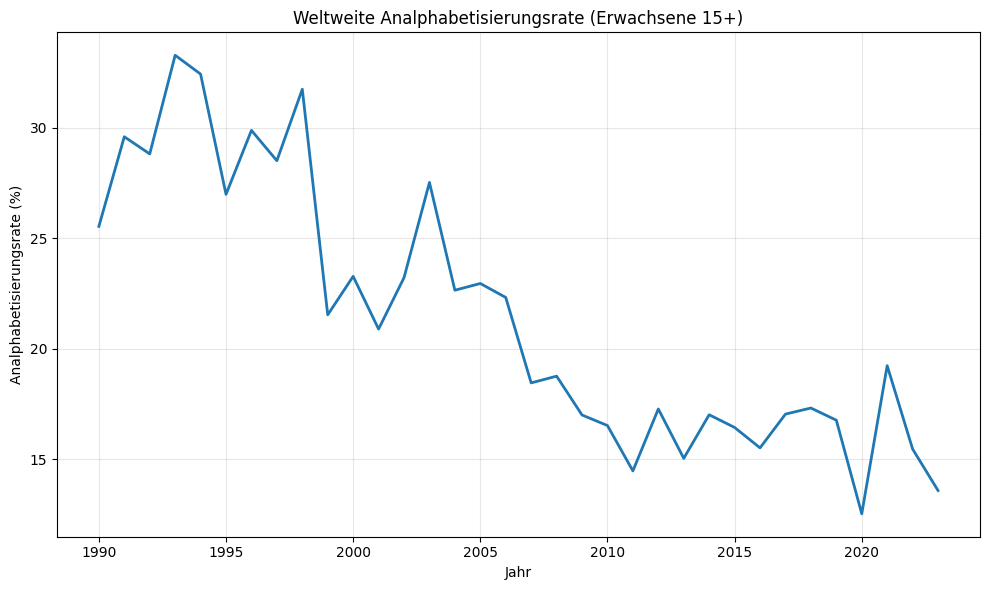

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. DATEN LADEN & BERECHNEN ---

df = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")
start_year = 1990
end_year = 2023

# Umbenennen und Filtern auf den globalen Zeitraum 1990-2023
df.rename(columns={'Year': 'Jahr', 'Literacy rate among adults': 'Alphabetisierungsrate'}, inplace=True)
df_global = df[(df['Jahr'] >= start_year) & (df['Jahr'] <= end_year)].copy()

# Berechnung der Analphabetisierungsrate
df_global['Analphabetisierungsrate (%)'] = 100 - df_global['Alphabetisierungsrate']

# Berechnung des weltweiten Durchschnitts pro Jahr
welt = df_global.groupby("Jahr")["Analphabetisierungsrate (%)"].mean().reset_index()

# --- 2. PLOT ERSTELLEN ---

plt.figure(figsize=(10, 6))
plt.plot(
    welt["Jahr"],
    welt["Analphabetisierungsrate (%)"], 
    linewidth=2
)


plt.title("Weltweite Analphabetisierungsrate (Erwachsene 15+)")
plt.xlabel("Jahr")
plt.ylabel("Analphabetisierungsrate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


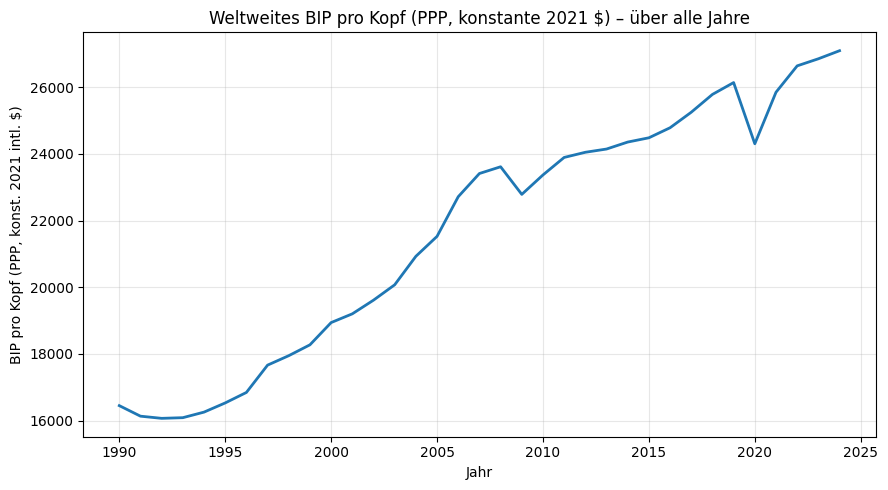

In [137]:
# Datei laden
df_gdp = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

gdp_col = "GDP per capita, PPP (constant 2021 international $)"

# Weltweiter Jahresdurchschnitt (ungewichtet)
world_gdp = (
    df_gdp.dropna(subset=[gdp_col])
    .groupby("Year")[gdp_col]
    .mean()
    .reset_index()
    .sort_values("Year")
)

# Plot
plt.figure(figsize=(9,5))
plt.plot(world_gdp["Year"], world_gdp[gdp_col], linewidth=2)
plt.title("Weltweites BIP pro Kopf (PPP, konstante 2021 $) – über alle Jahre")
plt.xlabel("Jahr")
plt.ylabel("BIP pro Kopf (PPP, konst. 2021 intl. $)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [139]:
import pandas as pd

# --- 1. DATENVORBEREITUNG (Definition des DataFrames) ---

file_path = "literacy-rate-vs-gdp-per-capita.csv"
countries = ["Afghanistan", "Iraq", "Sudan", "Syria"]
start_year = 1990
end_year = 2023

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"FEHLER: Die Datei '{file_path}' konnte nicht gefunden werden.")
    exit()

# Umbenennen für die Analyse
df.rename(columns={'Entity': 'Land', 'Year': 'Jahr'}, inplace=True)

# --- 2. KORRIGIERTE FILTERUNG & AUSGABE ---

# Filterung auf Zielländer und den Analysezeitraum (1990-2023)
df_laender = df[
    df["Land"].isin(countries) &
    (df["Jahr"] >= start_year) &
    (df["Jahr"] <= end_year)
].copy()

print("### Überblick über die gefilterten Daten der Zielländer (1990-2023) ###")
print(f"Es wurden {len(df_laender)} Zeilen gefunden.")

# Anzeige der ersten 5 Zeilen zur Überprüfung
print(df_laender.head().to_markdown(index=False))

### Überblick über die gefilterten Daten der Zielländer (1990-2023) ###
Es wurden 136 Zeilen gefunden.
| Land        | Code   |   Jahr |   Literacy rate among adults |   GDP per capita, PPP (constant 2021 international $) |   Population (historical) |   World regions according to OWID |
|:------------|:-------|-------:|-----------------------------:|------------------------------------------------------:|--------------------------:|----------------------------------:|
| Afghanistan | AFG    |   2011 |                      31      |                                               2757.05 |               2.93477e+07 |                               nan |
| Afghanistan | AFG    |   2015 |                      33.7538 |                                               2967.69 |               3.38318e+07 |                               nan |
| Afghanistan | AFG    |   2021 |                      37      |                                               2144.17 |               4.00004e+07 |         

In [141]:
import pandas as pd

# --- KONFIGURATION ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
COUNTRIES = ["Afghanistan", "Iraq", "Sudan", "Syria"]
START = 1990
END = 2023

# --- KERN-CODE ---

try:
    df = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# Umbenennen, Berechnen der Analphabetisierungsrate und Filtern
df.rename(columns={
    'Entity': 'Land', 
    'Year': 'Jahr', 
    'Literacy rate among adults': 'Alphabetisierungsrate'
}, inplace=True)
df['Analphabetisierungsrate (%)'] = 100 - df['Alphabetisierungsrate']

df_filtered = df[
    df["Land"].isin(COUNTRIES) & 
    (df["Jahr"] >= START) & 
    (df["Jahr"] <= END)
].copy()

# Aktuellste Daten pro Land finden
aktuell = (
    df_filtered
    .sort_values("Jahr") # Wichtig: Sortieren, damit tail(1) das neueste Jahr findet
    .groupby("Land", as_index=False)
    .tail(1)
    [["Land", "Jahr", "Analphabetisierungsrate (%)"]]
)

print("### Aktuellste Analphabetisierungsrate pro Land ###")
print(aktuell.to_markdown(index=False))

### Aktuellste Analphabetisierungsrate pro Land ###
| Land        |   Jahr |   Analphabetisierungsrate (%) |
|:------------|-------:|------------------------------:|
| Sudan       |   2023 |                           nan |
| Iraq        |   2023 |                           nan |
| Afghanistan |   2023 |                           nan |
| Syria       |   2023 |                           nan |


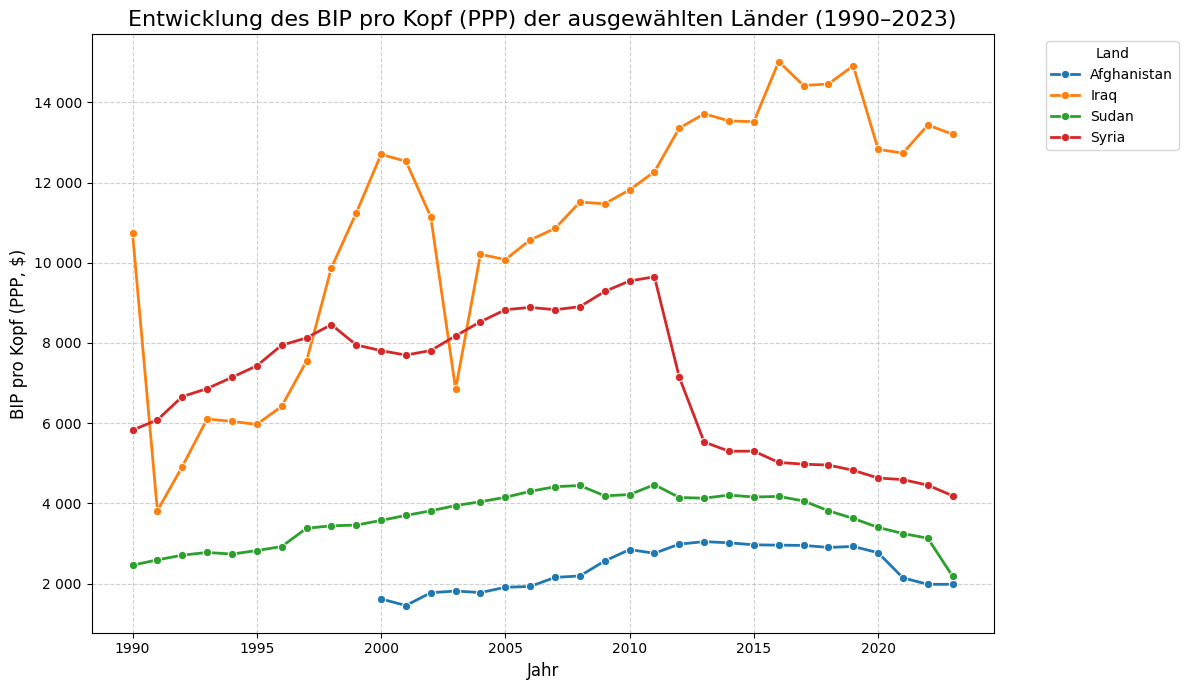

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- KONFIGURATION ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
COUNTRIES = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 
START = 1990
END = 2023

# --- KERN-CODE ---

try:
    df = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# Umbenennen und Filtern auf Zielländer und Zeitraum
df.rename(columns={
    'Entity': 'Land', 
    'Year': 'Jahr', 
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)

df_filtered = df[
    df['Land'].isin(COUNTRIES) & 
    (df['Jahr'] >= START) & 
    (df['Jahr'] <= END)
].dropna(subset=['BIP pro Kopf']).copy() # NaN-Werte für BIP entfernen

# --- PLOT ERSTELLEN ---

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_filtered,
    x='Jahr',
    y='BIP pro Kopf',
    hue='Land', 
    marker='o',
    dashes=False,
    linewidth=2
)


# Formatierung der y-Achse mit Tausender-Trennzeichen
formatter = FuncFormatter(lambda x, pos: '{:,.0f}'.format(x).replace(',', ' '))
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Entwicklung des BIP pro Kopf (PPP) der ausgewählten Länder (1990–2023)', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('BIP pro Kopf (PPP, $)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Land', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [146]:
df_gdp = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

df_gdp = df_gdp.rename(columns={
    "Entity": "Land",
    "Year": "Jahr",
    "GDP per capita, PPP (constant 2021 international $)": "BIP_pro_Kopf"
})

df_gdp.head()


,Land,Code,Jahr,Literacy rate among adults,BIP_pro_Kopf,Population (historical),World regions according to OWID
0,Afghanistan,AFG,1979,18.00000,NaN,13655575.0,NaN
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN


In [147]:
df_gdp = df_gdp.rename(columns={
    "Entity": "Land",
    "Year": "Jahr",
    "GDP per capita, PPP (constant 2021 international $)": "BIP_pro_Kopf"
})

df_gdp.head()


,Land,Code,Jahr,Literacy rate among adults,BIP_pro_Kopf,Population (historical),World regions according to OWID
0,Afghanistan,AFG,1979,18.00000,NaN,13655575.0,NaN
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN


In [148]:
laender = ["Afghanistan", "Iraq", "Sudan", "Syria"]

df_gdp_laender = df_gdp[df_gdp["Land"].isin(laender)]
df_gdp_laender.head()


,Land,Code,Jahr,Literacy rate among adults,BIP_pro_Kopf,Population (historical),World regions according to OWID
0,Afghanistan,AFG,1979,18.00000,NaN,13655575.0,NaN
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN


In [149]:
bip_aktuell = (
    df_gdp_laender
    .dropna(subset=["BIP_pro_Kopf"])
    .sort_values("Jahr")
    .groupby("Land", as_index=False)
    .tail(1)
    [["Land", "Jahr", "BIP_pro_Kopf"]]
)

bip_aktuell


,Land,Jahr,BIP_pro_Kopf
24,Afghanistan,2023,1983.8126
51677,Syria,2023,4189.8374
24871,Iraq,2024,12725.0430
50525,Sudan,2024,1871.5891


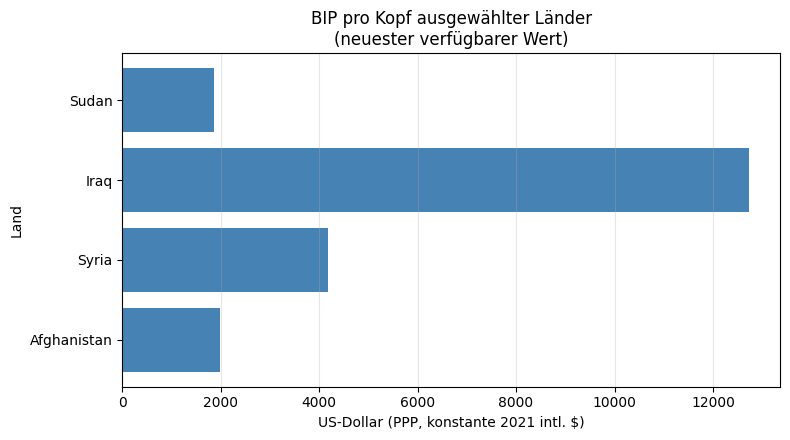

In [150]:
plt.figure(figsize=(8,4.5))

plt.barh(
    bip_aktuell["Land"],
    bip_aktuell["BIP_pro_Kopf"],
    color="steelblue"
)

plt.title("BIP pro Kopf ausgewählter Länder\n(neuester verfügbarer Wert)")
plt.xlabel("US-Dollar (PPP, konstante 2021 intl. $)")
plt.ylabel("Land")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [152]:
import pandas as pd

# --- KONFIGURATION & DATEN LADEN ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
COUNTRIES = ["Afghanistan", "Iraq", "Sudan", "Syria"]
START = 1990
END = 2023

try:
    df = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# Umbenennen und Berechnen der Analphabetisierungsrate
df.rename(columns={
    'Entity': 'Land', 
    'Year': 'Jahr', 
    'Literacy rate among adults': 'Alphabetisierungsrate',
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)
df['Analphabetisierungsrate (%)'] = 100 - df['Alphabetisierungsrate']

df_filtered = df[
    df["Land"].isin(COUNTRIES) & 
    (df["Jahr"] >= START) & 
    (df["Jahr"] <= END)
].copy()

# Aktuellste Daten pro Land finden
aktuell_all = (
    df_filtered
    .sort_values("Jahr") 
    .groupby("Land", as_index=False)
    .tail(1)
)

# --- KORRIGIERTER KERN-CODE ---

# Analphabetisierung (ersetzt 'ana') - KORREKTER SPALTENNAME
ana = aktuell_all[["Land", "Analphabetisierungsrate (%)"]]
 
# BIP (ersetzt 'bip') - KORREKTER SPALTENNAME
bip = aktuell_all[["Land", "BIP pro Kopf"]]
 
# Zusammenführen
vergleich = ana.merge(bip, on="Land")

print("### Vergleich der aktuellsten Analphabetisierungsrate und des BIP pro Kopf pro Land ###")
print(vergleich.to_markdown(index=False))


### Vergleich der aktuellsten Analphabetisierungsrate und des BIP pro Kopf pro Land ###
| Land        |   Analphabetisierungsrate (%) |   BIP pro Kopf |
|:------------|------------------------------:|---------------:|
| Sudan       |                           nan |        2181.08 |
| Iraq        |                           nan |       13202.3  |
| Afghanistan |                           nan |        1983.81 |
| Syria       |                           nan |        4189.84 |


In [157]:
import pandas as pd

# --- KONFIGURATION ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
COUNTRIES = ["Afghanistan", "Iraq", "Sudan", "Syria"]
START = 1990
END = 2023

# --- KERN-CODE ---

try:
    df = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden.")
    exit()

# Vorbereitung: Umbenennen, Berechnung der Analphabetisierungsrate und Filtern
df.rename(columns={
    'Entity': 'Land', 
    'Year': 'Jahr', 
    'Literacy rate among adults': 'Alphabetisierungsrate',
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)
df['Analphabetisierungsrate (%)'] = 100 - df['Alphabetisierungsrate']

df_filtered = df[
    df["Land"].isin(COUNTRIES) & 
    (df["Jahr"] >= START) & 
    (df["Jahr"] <= END)
].copy()

# Aktuellste Daten pro Land finden ('vergleich' DataFrame erstellen)
vergleich = (
    df_filtered
    .sort_values("Jahr") 
    .groupby("Land", as_index=False)
    .tail(1)
)

# Korrelation berechnen und ausgeben
korrelation = vergleich["BIP pro Kopf"].corr(
    vergleich["Analphabetisierungsrate (%)"]
)

print(f"Korrelation (Pearson's r): {korrelation:.4f}")


Korrelation (Pearson's r): nan


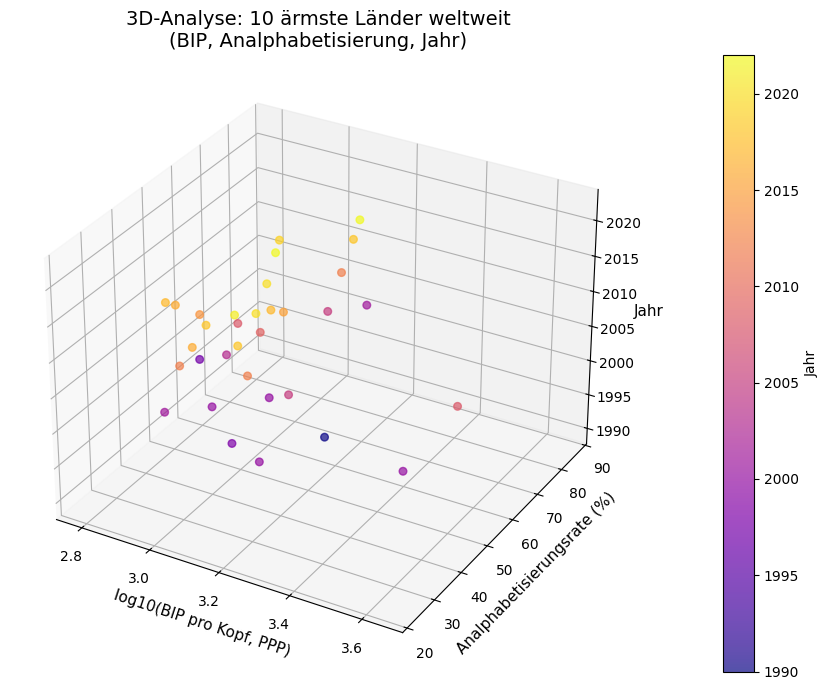

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Für 3D-Plot

# --- KONFIGURATION UND DATENVORBEREITUNG ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
GDP_COL_RAW = 'GDP per capita, PPP (constant 2021 international $)'
LITERACY_COL_RAW = 'Literacy rate among adults'
START_YEAR = 1985
END_YEAR = 2023
GDP_COL_ALIAS = 'BIP pro Kopf'

# Daten laden
try:
    df_rohdaten = pd.read_csv(FILE)
except FileNotFoundError:
    # Dieser Fehler tritt auf, wenn die Datei fehlt.
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# 1. Spalten umbenennen und Analphabetisierungsrate berechnen
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    LITERACY_COL_RAW: 'Alphabetisierungsrate',
    GDP_COL_RAW: GDP_COL_ALIAS # Wichtig: BIP pro Kopf als Alias setzen
}, inplace=True)

df_rohdaten['Analphabetisierungsrate (%)'] = 100 - df_rohdaten['Alphabetisierungsrate']


# 2. Ärmste 10 Länder finden
gdp_latest = (
    df_rohdaten
    .dropna(subset=[GDP_COL_ALIAS])
    .sort_values("Jahr")
    .groupby("Land", as_index=False)
    .tail(1)
)
poorest_10 = gdp_latest.nsmallest(10, GDP_COL_ALIAS)["Land"].tolist()


# 3. Daten für den 3D-Plot vorbereiten (Single Block)
df_3d = (
    df_rohdaten
    .query("Land in @poorest_10")
    .dropna(subset=['Analphabetisierungsrate (%)', GDP_COL_ALIAS])
)
df_3d = df_3d[(df_3d["Jahr"] >= START_YEAR) & (df_3d["Jahr"] <= END_YEAR)]


# --- 4. 3D PLOT ERSTELLEN ---

x = np.log10(df_3d[GDP_COL_ALIAS]) 
y = df_3d["Analphabetisierungsrate (%)"]
z = df_3d["Jahr"]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    x, y, z,
    c=z,
    cmap="plasma",
    s=30,
    alpha=0.7
)

ax.set_title("3D-Analyse: 10 ärmste Länder weltweit\n(BIP, Analphabetisierung, Jahr)", fontsize=14)
ax.set_xlabel("log10(BIP pro Kopf, PPP)", fontsize=11)
ax.set_ylabel("Analphabetisierungsrate (%)", fontsize=11)
ax.set_zlabel("Jahr", fontsize=11)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Jahr", fontsize=10)

plt.tight_layout()
plt.show()

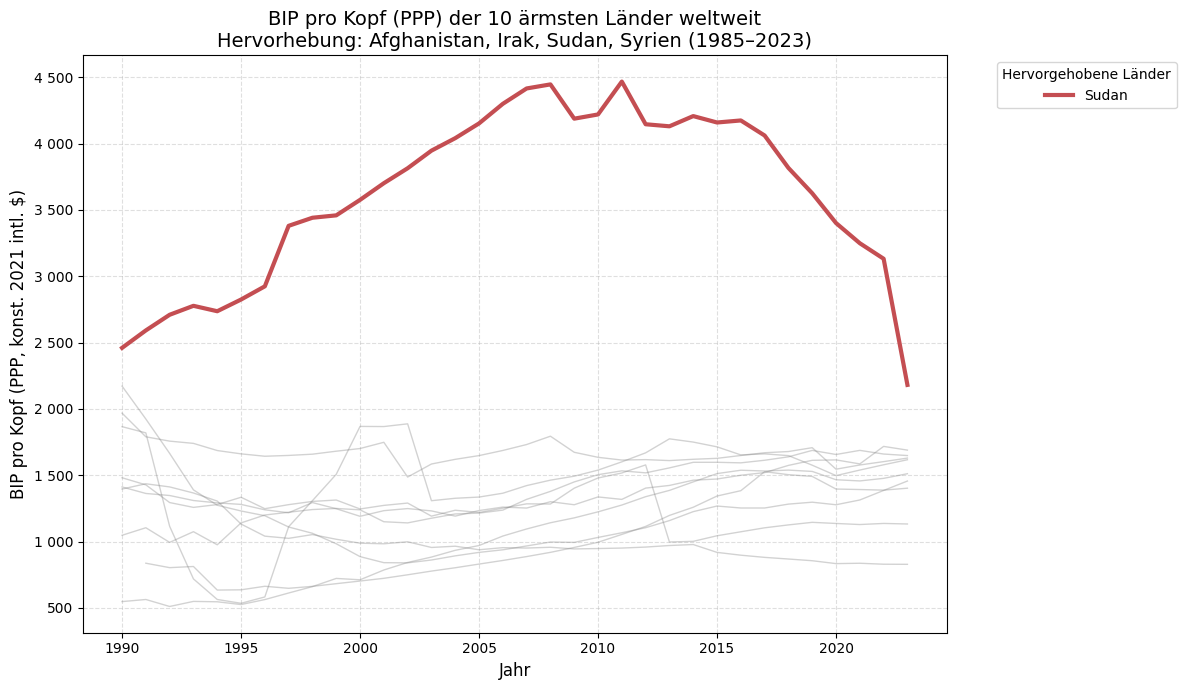

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- KONFIGURATION & DATEN LADEN ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
GDP_COL_RAW = 'GDP per capita, PPP (constant 2021 international $)'
START_YEAR = 1985
END_YEAR = 2023

# Die Länder, die hervorgehoben werden sollen
meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"] 

try:
    df_rohdaten = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# 1. Spalten umbenennen
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    GDP_COL_RAW: 'BIP pro Kopf'
}, inplace=True)

# 2. Ärmste 10 Länder finden (definiert 'alle_laender')
# Hier definieren wir die benötigten Variablen: 'gdp_col' und 'alle_laender'
gdp_col = 'BIP pro Kopf'

gdp_latest = (
    df_rohdaten
    .dropna(subset=[gdp_col])
    .sort_values("Jahr")
    .groupby("Land", as_index=False)
    .tail(1)
)

# Liste der 10 ärmsten Länder (definiert 'alle_laender')
alle_laender = gdp_latest.nsmallest(10, gdp_col)["Land"].tolist()

# 3. DataFrame für den Plot filtern (definiert 'df_plot')
df_plot = df_rohdaten[
    df_rohdaten['Land'].isin(alle_laender) &
    (df_rohdaten['Jahr'] >= START_YEAR) &
    (df_rohdaten['Jahr'] <= END_YEAR)
].copy()


# --- KORRIGIERTER PLOT CODE ---

plt.figure(figsize=(12, 7)) # Größe leicht angepasst für Lesbarkeit

for land in alle_laender:
    land_df = (
        df_plot[df_plot["Land"] == land]
        .sort_values("Jahr") # wichtig gegen Zickzack
    )
    
    # Hinzufügen der Formatierung für die Länder-Namen, damit sie übereinstimmen
    if land in [l.replace("Syria", "Syrian Arab Republic") for l in meine_laender]: # Beispiel: Manche Datensätze haben längere Namen
        
        # 🔥 Deine Länder hervorheben (Verwendung der korrigierten Spaltennamen)
        plt.plot(
            land_df["Jahr"],
            land_df[gdp_col],
            linewidth=3,
            label=land,
            color='#c44e52' # Eine auffällige Farbe
        )
    else:
        # Hintergrundländer
        plt.plot(
            land_df["Jahr"],
            land_df[gdp_col],
            linewidth=1,
            alpha=0.35,
            color='gray'
        )

# Formatierung der y-Achse (Tausender-Trennzeichen)
formatter = FuncFormatter(lambda x, pos: '{:,.0f}'.format(x).replace(',', ' '))
plt.gca().yaxis.set_major_formatter(formatter)

plt.title(
    "BIP pro Kopf (PPP) der 10 ärmsten Länder weltweit\n"
    "Hervorhebung: Afghanistan, Irak, Sudan, Syrien (1985–2023)",
    fontsize=14
)
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("BIP pro Kopf (PPP, konst. 2021 intl. $)", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')

plt.legend(
    title="Hervorgehobene Länder",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

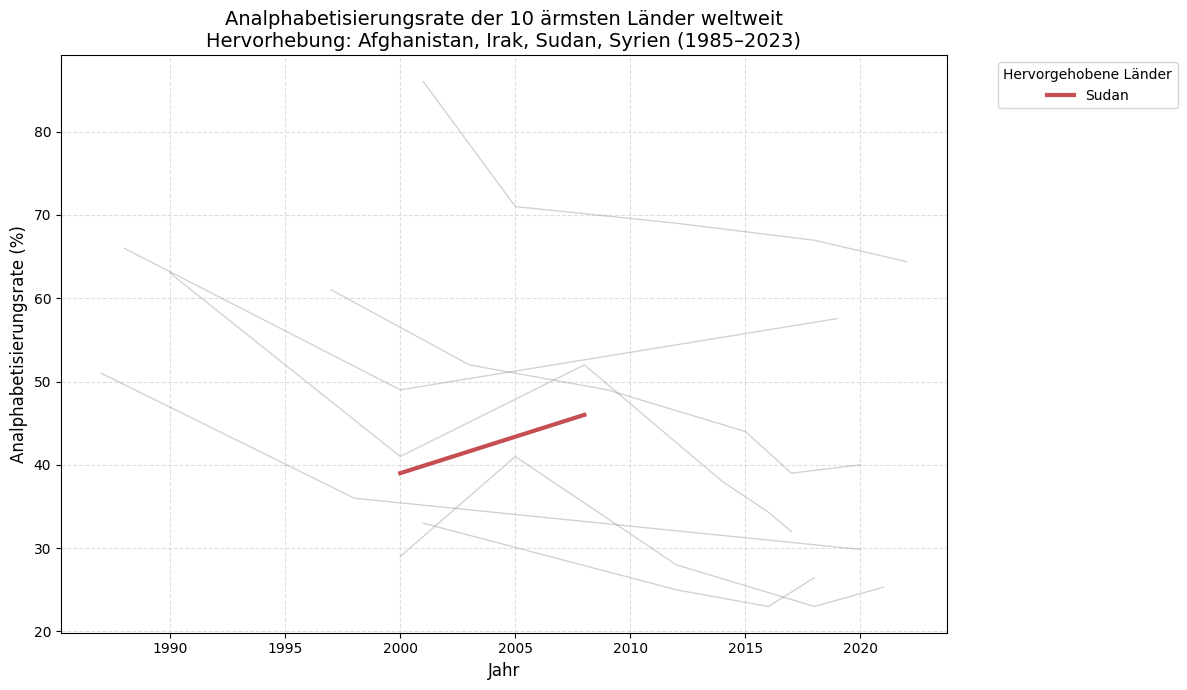

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- KONFIGURATION & DATEN LADEN ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
GDP_COL_RAW = 'GDP per capita, PPP (constant 2021 international $)'
LITERACY_COL_RAW = 'Literacy rate among adults'
START_YEAR = 1985
END_YEAR = 2023

# Die Länder, die hervorgehoben werden sollen
meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"] 

try:
    df_rohdaten = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# 1. Spalten umbenennen und Analphabetisierungsrate berechnen
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    LITERACY_COL_RAW: 'Alphabetisierungsrate',
    GDP_COL_RAW: 'BIP pro Kopf'
}, inplace=True)

# Berechnung der benötigten Spalte!
df_rohdaten['Analphabetisierungsrate (%)'] = 100 - df_rohdaten['Alphabetisierungsrate']

# 2. Ärmste 10 Länder finden (definiert 'alle_laender')
# Hier definieren wir die benötigten Variablen: 'alle_laender'
gdp_col = 'BIP pro Kopf' # Für die nsmallest Funktion

gdp_latest = (
    df_rohdaten
    .dropna(subset=[gdp_col])
    .sort_values("Jahr")
    .groupby("Land", as_index=False)
    .tail(1)
)

# Liste der 10 ärmsten Länder
alle_laender = gdp_latest.nsmallest(10, gdp_col)["Land"].tolist()

# 3. DataFrame für den Plot filtern (definiert 'df_plot_lit')
# Wir benötigen nur Daten der 10 ärmsten Länder im Analysezeitraum
df_plot_lit = df_rohdaten[
    df_rohdaten['Land'].isin(alle_laender) &
    (df_rohdaten['Jahr'] >= START_YEAR) &
    (df_rohdaten['Jahr'] <= END_YEAR)
].copy()


# --- KORRIGIERTER PLOT CODE ---

plt.figure(figsize=(12, 7)) # Größe angepasst

for land in alle_laender:
    land_df = (
        df_plot_lit[df_plot_lit["Land"] == land] # Korrigiert: 'Entity' zu 'Land'
        .sort_values("Jahr") 
        .dropna(subset=['Analphabetisierungsrate (%)']) # Nur Länder mit Daten plotten
    )
    
    # Hervorhebung prüfen
    if land in meine_laender:
        # 🔴 Deine Länder – hervorheben
        plt.plot(
            land_df["Jahr"],
            land_df["Analphabetisierungsrate (%)"], # KORRIGIERTER SPALTENNAME
            linewidth=3,
            label=land,
            color='#c44e52' # Eine auffällige Farbe
        )
    else:
        # ⚪ Andere Länder – Hintergrund
        plt.plot(
            land_df["Jahr"],
            land_df["Analphabetisierungsrate (%)"], # KORRIGIERTER SPALTENNAME
            linewidth=1,
            alpha=0.35,
            color='gray'
        )



plt.title(
    "Analphabetisierungsrate der 10 ärmsten Länder weltweit\n"
    "Hervorhebung: Afghanistan, Irak, Sudan, Syrien (1985–2023)",
    fontsize=14
)
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("Analphabetisierungsrate (%)", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')

plt.legend(
    title="Hervorgehobene Länder",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [164]:
import pandas as pd

# --- KONFIGURATION & DATEN LADEN ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
GDP_COL_RAW = 'GDP per capita, PPP (constant 2021 international $)'

try:
    # Laden des gesamten DataFrames (entspricht Ihrer 'gdp' Variable, da BIP enthalten ist)
    df_rohdaten = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# 1. Spalten umbenennen (definiert den Spaltennamen)
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    GDP_COL_RAW: 'BIP pro Kopf' # Entspricht Ihrer 'gdp_col'
}, inplace=True)

# Spaltennamen-Alias setzen
gdp_col_alias = 'BIP pro Kopf'

# --- KORRIGIERTER KERN-CODE ---

# Neuester BIP-Wert pro Land (definiert 'latest_rich')
latest_rich = (
    df_rohdaten
    # dropna(subset=[gdp_col]) -> mit Alias
    .dropna(subset=[gdp_col_alias])
    # sort_values("Year") -> mit Alias
    .sort_values("Jahr") 
    # groupby("Entity") -> mit Alias
    .groupby("Land", as_index=False) 
    .tail(1)
)
 
# 10 reichste Länder
# nlargest(10, gdp_col)["Entity"] -> mit Aliasen
richest_10 = latest_rich.nlargest(10, gdp_col_alias)["Land"].tolist()

print("### 10 Länder mit dem höchsten BIP pro Kopf (Neuester verfügbarer Wert) ###")
print(richest_10)

### 10 Länder mit dem höchsten BIP pro Kopf (Neuester verfügbarer Wert) ###
['Singapore', 'Luxembourg', 'Ireland', 'Macao', 'Qatar', 'Bermuda', 'Norway', 'Switzerland', 'Brunei', 'Cayman Islands']


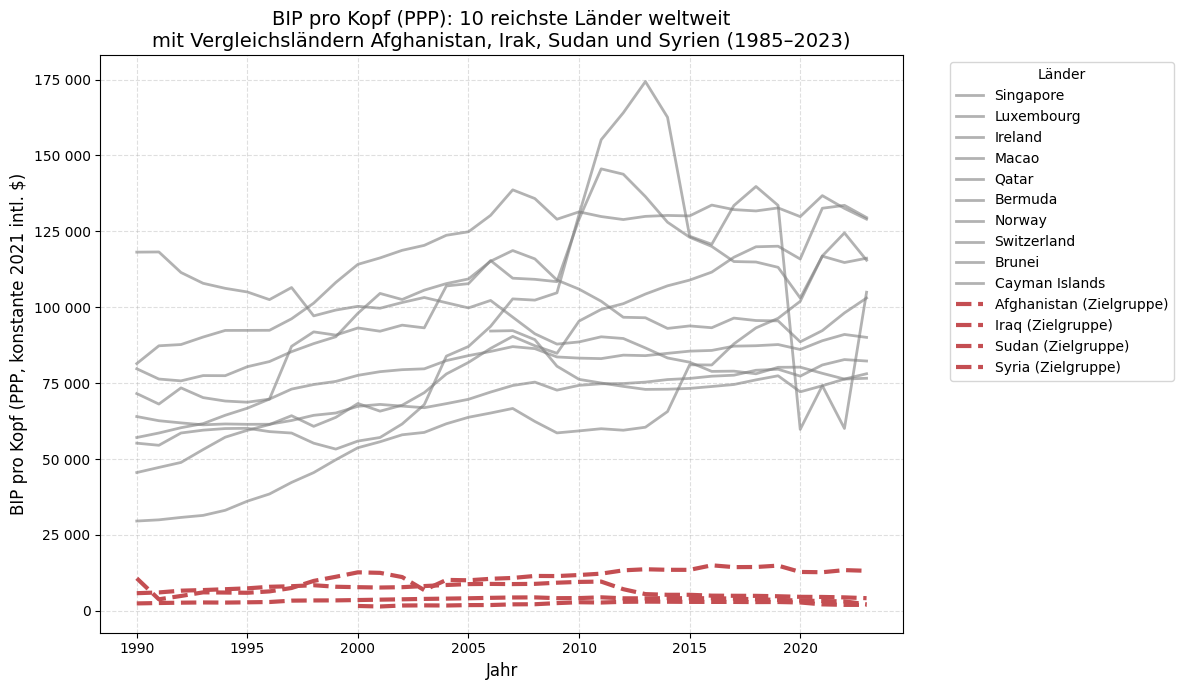

✅ Liniendiagramm zum Vergleich BIP: Reichste Länder vs. Zielgruppe wurde erstellt.


In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- KONFIGURATION & DATEN LADEN ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
GDP_COL_RAW = 'GDP per capita, PPP (constant 2021 international $)'
START_YEAR = 1985
END_YEAR = 2023

# Die Länder, die hervorgehoben werden sollen (Zielgruppe)
meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"] 

try:
    df_rohdaten = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# 1. Spalten umbenennen (definiert die Aliase 'Land' und 'BIP pro Kopf')
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    GDP_COL_RAW: 'BIP pro Kopf'
}, inplace=True)
gdp_col = 'BIP pro Kopf' # Definition des Aliases

# 2. 10 reichste Länder finden (definiert 'richest_10')
gdp_latest = (
    df_rohdaten
    .dropna(subset=[gdp_col])
    .sort_values("Jahr")
    .groupby("Land", as_index=False)
    .tail(1)
)
richest_10 = gdp_latest.nlargest(10, gdp_col)["Land"].tolist()

# 3. DataFrame auf den Analysezeitraum einschränken (df_plot)
df_plot = df_rohdaten[
    (df_rohdaten['Jahr'] >= START_YEAR) &
    (df_rohdaten['Jahr'] <= END_YEAR)
].copy()


# --- KORRIGIERTER PLOT CODE ---

plt.figure(figsize=(12, 7)) # Größe leicht angepasst

# 10 reichste Länder (Hintergrund)
for land in richest_10:
    land_df = (
        df_plot[df_plot["Land"] == land] # Korrigiert: 'Entity' zu 'Land'
        .sort_values("Jahr")
    )
    plt.plot(
        land_df["Jahr"],
        land_df[gdp_col],
        linewidth=2,
        alpha=0.6,
        label=land,
        color='grey' # Standardfarbe für die reichsten Länder
    )

# Deine Länder (Hervorhebung)
for land in meine_laender:
    land_df = (
        df_plot[df_plot["Land"] == land] # Korrigiert: 'Entity' zu 'Land'
        .sort_values("Jahr")
    )
    if not land_df.empty:
        # Hervorhebung der Zielländer mit markanter Farbe/Linienstil
        plt.plot(
            land_df["Jahr"],
            land_df[gdp_col],
            linewidth=3,
            linestyle="--",
            label=f"{land} (Zielgruppe)",
            color='#c44e52' # Rote/Auffällige Farbe für die Zielgruppe
        )



# Formatierung der y-Achse (Tausender-Trennzeichen)
formatter = FuncFormatter(lambda x, pos: '{:,.0f}'.format(x).replace(',', ' '))
plt.gca().yaxis.set_major_formatter(formatter)

plt.title(
    "BIP pro Kopf (PPP): 10 reichste Länder weltweit\n"
    "mit Vergleichsländern Afghanistan, Irak, Sudan und Syrien (1985–2023)",
    fontsize=14
)
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("BIP pro Kopf (PPP, konstante 2021 intl. $)", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')

plt.legend(
    title="Länder",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

print("✅ Liniendiagramm zum Vergleich BIP: Reichste Länder vs. Zielgruppe wurde erstellt.")

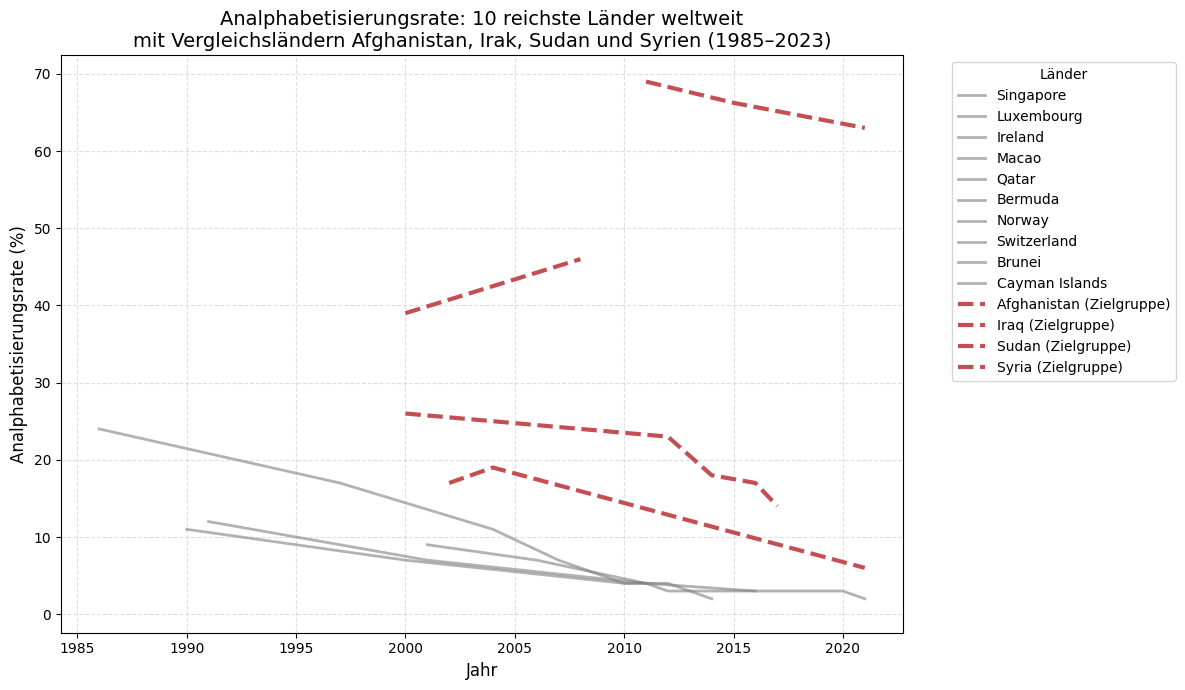

✅ Liniendiagramm zum Vergleich Analphabetisierungsrate: Reichste Länder vs. Zielgruppe wurde erstellt.


In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- KONFIGURATION & DATEN LADEN ---
FILE = "literacy-rate-vs-gdp-per-capita.csv"
GDP_COL_RAW = 'GDP per capita, PPP (constant 2021 international $)'
LITERACY_COL_RAW = 'Literacy rate among adults'
START_YEAR = 1985
END_YEAR = 2023

# Die Länder, die hervorgehoben werden sollen (Zielgruppe)
meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"] 

try:
    df_rohdaten = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# 1. Spalten umbenennen und Analphabetisierungsrate berechnen (definiert 'lit')
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    LITERACY_COL_RAW: 'Alphabetisierungsrate',
    GDP_COL_RAW: 'BIP pro Kopf'
}, inplace=True)

df_rohdaten['Analphabetisierungsrate (%)'] = 100 - df_rohdaten['Alphabetisierungsrate']
lit = df_rohdaten.copy() # Entspricht Ihrer 'lit' Variable

# 2. 10 reichste Länder finden (definiert 'richest_10')
gdp_col = 'BIP pro Kopf'
gdp_latest = (
    df_rohdaten
    .dropna(subset=[gdp_col])
    .sort_values("Jahr")
    .groupby("Land", as_index=False)
    .tail(1)
)
richest_10 = gdp_latest.nlargest(10, gdp_col)["Land"].tolist()

# 3. DataFrame auf den Analysezeitraum einschränken (df_plot)
df_plot = df_rohdaten[
    (df_rohdaten['Jahr'] >= START_YEAR) &
    (df_rohdaten['Jahr'] <= END_YEAR)
].copy()


# --- KORRIGIERTER PLOT CODE ---

plt.figure(figsize=(12, 7)) # Größe leicht angepasst

# 10 reichste Länder (Hintergrund)
for land in richest_10:
    land_df = (
        df_plot[df_plot["Land"] == land]
        .sort_values("Jahr")
        .dropna(subset=['Analphabetisierungsrate (%)']) # Nur Länder mit Daten plotten
    )
    plt.plot(
        land_df["Jahr"],
        land_df["Analphabetisierungsrate (%)"], # KORRIGIERTER SPALTENNAME
        linewidth=2,
        alpha=0.6,
        label=land,
        color='grey' # Standardfarbe
    )

# Deine Länder (Hervorhebung)
for land in meine_laender:
    land_df = (
        df_plot[df_plot["Land"] == land]
        .sort_values("Jahr")
        .dropna(subset=['Analphabetisierungsrate (%)'])
    )
    if not land_df.empty:
        # Hervorhebung der Zielländer mit markanter Farbe/Linienstil
        plt.plot(
            land_df["Jahr"],
            land_df["Analphabetisierungsrate (%)"], # KORRIGIERTER SPALTENNAME
            linewidth=3,
            linestyle="--",
            label=f"{land} (Zielgruppe)",
            color='#c44e52' # Rote/Auffällige Farbe
        )



plt.title(
    "Analphabetisierungsrate: 10 reichste Länder weltweit\n"
    "mit Vergleichsländern Afghanistan, Irak, Sudan und Syrien (1985–2023)",
    fontsize=14
)
plt.xlabel("Jahr", fontsize=12)
plt.ylabel("Analphabetisierungsrate (%)", fontsize=12)
plt.grid(alpha=0.4, linestyle='--')

plt.legend(
    title="Länder",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

print("✅ Liniendiagramm zum Vergleich Analphabetisierungsrate: Reichste Länder vs. Zielgruppe wurde erstellt.")

## 2. Daten vorbereiten 
- Die Roh-Daten sind bereits im Long-Format
- Für die Analyse werden die Daten pivotiert: Jede Spalte repräsentiert eine Region, die Zeilen sind die verschiedenen Jahre - in absteigender Reihenfolge.

In [92]:
df.columns

Index(['Entity', 'Code', 'Year',
       'Literacy rate, adult total (% of people ages 15 and above)'],
      dtype='object')

In [93]:
df_filtered = df[(df["Year"] >= 1985) & (df["Year"] <= 2025)]
df_filtered.head()

,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)"
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000
5,Albania,ALB,2008,96.00000


## 3. Statistik der Roh-Daten (Analyse im Long-Format)

über die einzelnen Spalten kann folgendes ausgesagt werden:
- Die Spalte *Gebiete* enthält 261 verschieden Gebiete
- Die Spalte *Codes* enthält 239 verschiedene Codes
- Es sind Daten zwischen 1543 and 2021 vorhanden. Ab dem Jahr 1950 sind die Daten komplett
- Die Lebenserwartung streut zwischen 12 und 86.5 Jahren

In [105]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1528 entries, 0 to 1527
Data columns (total 4 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Entity                                                      1528 non-null   object 
 1   Code                                                        1117 non-null   object 
 2   Year                                                        1528 non-null   int64  
 3   Literacy rate, adult total (% of people ages 15 and above)  1528 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 47.9+ KB


Index(['Entity', 'Code', 'Year',
       'Literacy rate, adult total (% of people ages 15 and above)'],
      dtype='object')

### 3.1 Analyse Gebiete

In [95]:
print('Anzahl verschiedener Gebiete: ', len(df['Entity'].unique()))

Anzahl verschiedener Gebiete:  179


In [106]:
# Anzahl Datenpunkte pro Gebiet
df['Entity'].value_counts()

Entity
Latin America and Caribbean (WB)                            50
Middle East, North Africa, Afghanistan and Pakistan (WB)    50
Lower-middle-income countries                               49
South Asia (WB)                                             49
East Asia and Pacific (WB)                                  48
                                                            ..
Kiribati                                                     1
Marshall Islands                                             1
Israel                                                       1
Solomon Islands                                              1
San Marino                                                   1
Name: count, Length: 179, dtype: int64

<Axes: title={'center': 'Anzahl Datenpunkte pro Gebiet'}, xlabel='Entity', ylabel='Anzahl Datenpunkte'>

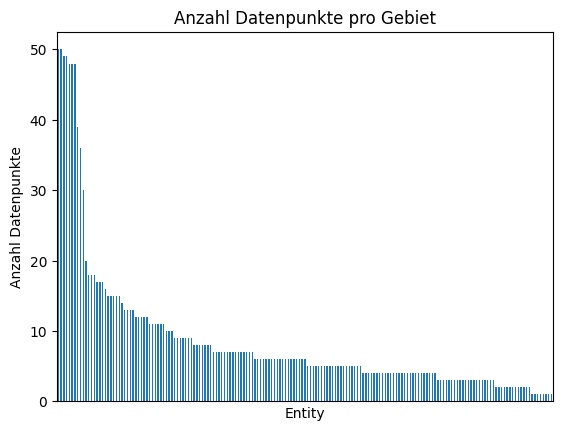

In [109]:
df['Entity'].value_counts().plot(kind='bar', 
                                 xticks=[],     # disable labels on x-axis
                                 ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Gebiet')

### 3.2 Analyse Codes

In [98]:
print('Anzahl verschiedener Codes: ', len(df['Code'].unique()))

Anzahl verschiedener Codes:  170


In [99]:
# Anzahl Datenpunkte pro Gebiet
df['Code'].value_counts()

Code
OWID_WRL    48
MEX         20
PSE         18
TUR         18
URY         18
            ..
JAM          1
MHL          1
KIR          1
SMR          1
SLB          1
Name: count, Length: 169, dtype: int64

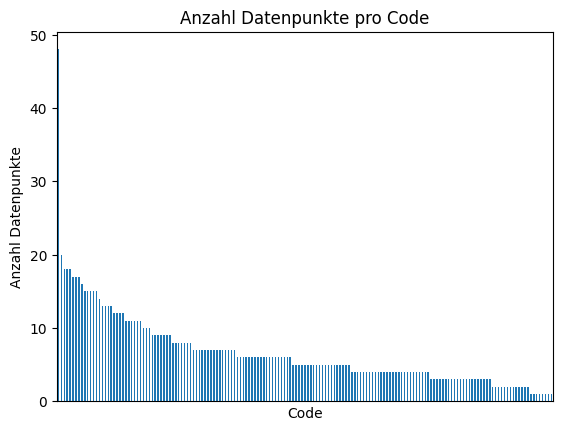

In [100]:
df['Code'].value_counts().plot(kind='bar',xticks=[], ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Code');

### 3.3 Analyse Jahr

In [101]:
print('Anzahl verschiedener Jahre: ', len(df['Jahr'].unique()))

KeyError: 'Jahr'

In [ ]:
# Anzahl Datenpunkte pro Jahr
df['Jahr'].value_counts().sort_index()

In [ ]:
# Jahre mit maximaler Anzahl Datenpunkte (257)
g = df['Jahr'].value_counts().sort_index().plot(ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Jahr');
g.axvline(x=1950, color='red',label='1950') # rote Linie bei 1950 - ab hier sind alle Jahre enthalten
g.legend()  # Legende anzeigen

### 3.4 Analyse Lebenserwartung

In [ ]:
df.describe()

In [ ]:
g = df['Lebenserwartung'].plot(kind='hist', bins=20, title='Histogramm der Lebenserwartung', 
                           xlabel='Lebenserwartung', ylabel='Anzahl Datenpunkte')
mean = df['Lebenserwartung'].mean()
g.axvline(x=df['Lebenserwartung'].mean(), color='red',label=f'Mittelwert = {mean:.2f}')  # rote Linie bei Mittelwert

median = df['Lebenserwartung'].median()
g.axvline(x=df['Lebenserwartung'].median(), color='orange',label=  f'Median = {median:.2f}')  # orange Linie bei Median

g.legend()




## 4. Analyse 

### Vorgehen

### Beobachtungen
- Afrikanische Länder sind an der Spitze in der Zunahme der Lebenserwartung. Eine Zunahme der Lebenserwartung von mehr als 5 Jahren haben: Uganda, Tanzania, Malawi, Zimbabwe, Lesotho, Swasiland
- Eine Reduktion der Lebenserwartung von mehr als 4 Jahren haben: Saint Vincent and the Grenadines, Mexiko, Kuba, Oman


### Interpretation

Corona führte bei allen Ländern zu einer Reduktion der Lebenserwartung (siehe Plot)

Länder (in Afrika) mit starker Zunahme der Lebensqualität:
- Bei den afrikanischen Ländern stieg die Lebenserwartung in den letzten Jahren sehr stark, da die Lebenserwartung sehr tief war. Zudem ist der Effekt von Corona auf die Lebenserwartung in den afrikanischen Ländern eher kleiner weil die Bevölkerung jünger ist
- Bei einigen afrikanischen Ländern hat sich die Lebenserwartung zwischen 1990 und 2000 stark verringert wegen HIV. Siehe Beispielsweise: https://life4me.plus/pl/news/life-expectancy-in-zimbabwe-shoots-up-hiv-infection-drop/


Länder mit einer starken Reduktion der Lebensqualität:
- Hier war die Lebenserwartung in den Jahren vor Corona konstant. Corona führte dann zu einer Reduktion der Lebenserwartung


### Berechnungen

In [ ]:
diffs = df_pivot[2021]-df_pivot[2011]   # Differenz zwischen 2021 und 2011
diffs = diffs.sort_values().dropna()  # sortieren nach Differenz und NaN-Werte entfernen
diffs

In [ ]:
diff_sel = (diffs < -4) | (diffs > 5)  # Auswahl der grössten und kleinsten Differenzen
diffs[diff_sel].plot(kind='barh', title='Grösste und kleinste Differenzen der Lebenserwartung 2011-2021')

In [ ]:
Gebiets_liste = diffs[diff_sel].index.tolist()  # Liste der Gebiete mit grössten und kleinsten Differenzen
print(Gebiets_liste)

### Visualisierung

In [ ]:
color_dict = {
    'Saint Vincent and the Grenadines': 'blue',
    'Mexico': 'cyan',
    'Cuba': 'lightgreen',
    'Oman': 'green',
    'Tanzania': 'red',
    'Sierra Leone': 'orange',
    'Malawi': 'yellow',
    'Zimbabwe': 'brown',
    'Lesotho': 'pink',
    'Eswatini': 'purple'
}

for gebiet in Gebiets_liste:
    diff = diffs[gebiet]
    g = df_pivot.loc[gebiet].plot(title='Lebenserwartungen', xlabel='Jahr', ylabel=f'Lebenserwartung', legend=True,
                                  label=f'{gebiet} - Diff. 2021-2011: {diff:.2f}', # für die Legende
                                  xlim=[1980,2025], ylim=[0,80],   # x- und y-Achsen begrenzen
                                  color=color_dict[gebiet],        # Farbe aus color_dict
                                  figsize=(7,7))                   # Grösse des Plots

# Covid Pandemie    
g.axvline(x=2020, color='black', linestyle='--') 
g.text(2020.5, 37, 'Covid')  

# HIV Pandemie
g.axvline(x=2005, color='black', linestyle='--')  
g.text(2005.5, 37, 'HIV');